Problem Statement: The problem is to predict the safety of the car

Dataset description: I have used the Car Evaluation Data Set downloaded from the Kaggle website. I have downloaded this data set from the Kaggle website. The data set can be found at the following url:-

http://archive.ics.uci.edu/ml/datasets/Car+Evaluation

Car Evaluation Database was derived from a simple hierarchical decision model originally developed for expert system for decision making. The Car Evaluation Database contains examples with the structural information removed, i.e., directly relates CAR to the six input attributes: buying, maint, doors, persons, lug_boot, safety

# 1. Import Libraries

In [344]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

# 2. Load Dataset

In [345]:
# load dataset
df = pd.read_csv("Datasets/car.data", header = None)

In [346]:
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


# 3. Exploratory data analysis


Now, I will explore the data to gain insights about the data.

In [347]:
# view dimensions of dataset
df.shape

(1728, 7)

In [348]:
# preview the dataset
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


Rename column names

We can see that the dataset does not have proper column names. The columns are merely labelled as 0,1,2.... and so on. We should give proper names to the columns. I will do it as follows:-

In [349]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df.columns = col_names

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


We can see that the column names are renamed. Now, the columns have meaningful names.

In [350]:
# view summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 47.3 KB


In [351]:
# Convert car columns to object type - because original data is object type.
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

for col in col_names:
    df[col] = df[col].astype('category')

In [352]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   buying    1728 non-null   category
 1   maint     1728 non-null   category
 2   doors     1728 non-null   category
 3   persons   1728 non-null   category
 4   lug_boot  1728 non-null   category
 5   safety    1728 non-null   category
 6   class     1728 non-null   category
dtypes: category(7)
memory usage: 12.1 KB


In [353]:
# Frequency distribution of values in variables - Now, I will check the frequency counts of categorical variables.

for col in df.columns:
    print(df[col].value_counts())


buying
high     432
low      432
med      432
vhigh    432
Name: count, dtype: int64
maint
high     432
low      432
med      432
vhigh    432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
big      576
med      576
small    576
Name: count, dtype: int64
safety
high    576
low     576
med     576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


Summary of variables: There are 7 variables in the dataset. All the variables are of categorical data type.

These are given by buying, maint, doors, persons, lug_boot, safety and class.

class is the target variable.

In [354]:
# chekc for missing values
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

No Missing value in data

# 4. Declare feature and target variable

In [355]:
X = df.drop(columns = 'class')

y = df['class']

# 5. Split data into separate training and test set

In [356]:
from sklearn.model_selection import train_test_split

In [357]:
# perform train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state =  42)

In [358]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((1209, 6), (519, 6))

# 6. Perform Feature Engineering

Feature Engineering is the process of transforming raw data into useful features that help us to understand our model better and increase its predictive power. I will carry out feature engineering on different types of variables.

In [359]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
1178,med,med,5more,4,big,high
585,high,high,3,more,small,low
1552,low,med,3,4,med,med
1169,med,med,5more,2,big,high
1033,med,high,4,2,big,med


We can see that all the variables are ordinal categorical data type.

In [360]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

X_train_encoder = encoder.fit_transform(X_train)

X_test_encoder = encoder.transform(X_test)

# 7. Random Forest Classifier model

In [361]:
# # import Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

# instantiate the classifier

rfc = RandomForestClassifier(n_estimators=100, random_state = 42, max_depth = 7)

# fit the model

rfc.fit(X_train_encoder, y_train )

# Predict the Train set results

y_pred_train = rfc.predict(X_train_encoder)

# Predict the Test set results

y_pred_test = rfc.predict(X_test_encoder)

In [362]:
# Check accuracy score 

from sklearn.metrics import accuracy_score

print('Training Model accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

print('Testing Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Training Model accuracy score: 0.9471
Testing Model accuracy score: 0.9268


In [363]:
# view the feature scores

feature_scores = pd.Series(rfc.feature_importances_, index = X_train.columns).sort_values(ascending=False)

feature_scores

safety      0.333813
persons     0.296700
buying      0.144082
maint       0.121382
lug_boot    0.065324
doors       0.038699
dtype: float64

We can see that the most important feature is safety and least important feature is doors.

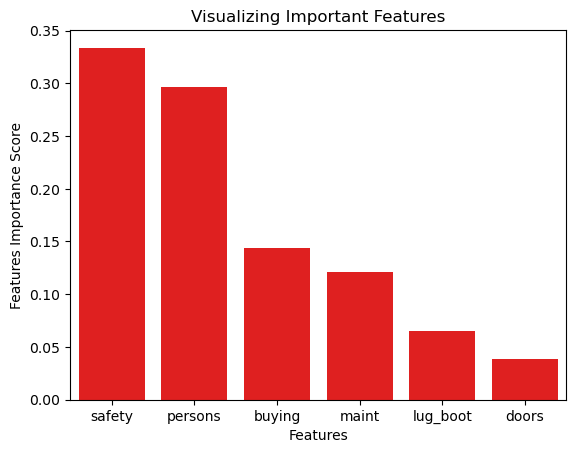

In [364]:
sns.barplot(feature_scores, color = 'red')

plt.xlabel('Features')
plt.ylabel('Features Importance Score')

plt.title("Visualizing Important Features")

plt.show()


# 8. Build the Random Forest model on selected features - Fine tune model

[buying, maint, persons, ug_boot, safety, class]

In [416]:
# copy data set
df_copy = df.copy()
df_copy.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,high,high,2,2,big,high,unacc
freq,432,432,432,576,576,576,1210


In [417]:
X_c = df_copy.drop(columns = ['class', 'doors'])
y_c = df_copy['class']

In [418]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size = 0.3, random_state =  42)

In [419]:
encoder_c = OrdinalEncoder()

X_train_c_encoder = encoder_c.fit_transform(X_train_c)

X_test_c_encoder = encoder_c.transform(X_test_c)

In [420]:
# # import Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

# instantiate the classifier

rfc_c = RandomForestClassifier(n_estimators=100, random_state = 42, max_depth = 7, class_weight='balanced')

# fit the model

rfc_c.fit(X_train_c_encoder, y_train_c )

# Predict the Train set results

y_pred_c_train = rfc_c.predict(X_train_c_encoder)

# Predict the Test set results

y_pred_c_test = rfc_c.predict(X_test_c_encoder)

In [421]:
# Check accuracy score 

from sklearn.metrics import accuracy_score

print('Training Model accuracy score: {0:0.4f}'. format(accuracy_score(y_train_c, y_pred_c_train)))

print('Testing Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test_c, y_pred_c_test)))

Training Model accuracy score: 0.9355
Testing Model accuracy score: 0.9326


In [424]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

print('Confusion matrix\n\n', cm)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

Confusion matrix

 [[105   0  12   1]
 [ 19   0   0   0]
 [  3   0 355   0]
 [  3   0   0  21]]


/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

         acc       0.81      0.89      0.85       118
        good       0.00      0.00      0.00        19
       unacc       0.97      0.99      0.98       358
       vgood       0.95      0.88      0.91        24

    accuracy                           0.93       519
   macro avg       0.68      0.69      0.68       519
weighted avg       0.90      0.93      0.91       519



In [425]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm2 = confusion_matrix(y_test_c, y_pred_c_test)

print('Confusion matrix\n\n', cm2)

from sklearn.metrics import classification_report

print(classification_report(y_test_c, y_pred_c_test))

Confusion matrix

 [[ 98  12   0   8]
 [  0  16   0   3]
 [ 12   0 346   0]
 [  0   0   0  24]]
              precision    recall  f1-score   support

         acc       0.89      0.83      0.86       118
        good       0.57      0.84      0.68        19
       unacc       1.00      0.97      0.98       358
       vgood       0.69      1.00      0.81        24

    accuracy                           0.93       519
   macro avg       0.79      0.91      0.83       519
weighted avg       0.94      0.93      0.94       519



**Model Performance Summary**

The Random Forest model achieved an overall **accuracy of 93%** on the test dataset. It performed exceptionally well in classifying the `unacc` class (F1-score: **0.98**) and showed strong performance for the `acc` (F1-score: **0.86**) and `vgood` (F1-score: **0.81**) classes. The model also demonstrated a significant improvement in identifying the minority `good` class, achieving a **recall of 0.84** and an **F1-score of 0.68**. The **macro F1-score of 0.83** indicates balanced performance across all classes despite class imbalance. Overall, the Random Forest classifier provides accurate, reliable, and well-balanced predictions, making it an effective model for the Car Evaluation dataset.
